# Algoritmos Genéticos aplicados a Machine Learning
## Notebook 2: Optimización de Hiperparámetros (Hyperparameter Optimization) con Algoritmos Genéticos



**Objetivo:** usar un Algoritmo Genético para explorar el espacio de hiperparámetros de un **Random Forest** y encontrar la combinación que maximiza el desempeño de clasificación, comparando el resultado contra los hiperparámetros por defecto y discutiendo el enfoque frente a Grid Search / Random Search.

**Dataset:** el mismo dataset real **Breast Cancer Wisconsin (Diagnostic)** de scikit-learn (569 pacientes, 30 variables reales, diagnóstico maligno/benigno) usado en el Notebook 1, para mantener continuidad entre los tres experimentos.

---
### 1. ¿Por qué un AG para optimizar hiperparámetros?

Un Random Forest tiene varios hiperparámetros continuos y discretos (`n_estimators`, `max_depth`, `min_samples_split`, `min_samples_leaf`, `max_features`) cuyo espacio conjunto es demasiado grande para explorar exhaustivamente (Grid Search) y donde Random Search no aprovecha la información de las combinaciones ya evaluadas. Un AG sí aprovecha esa información: las combinaciones buenas ("padres") se combinan y mutan para generar nuevas combinaciones probablemente mejores, guiando la búsqueda de forma más eficiente que el azar puro.


In [1]:
# =========================================================
# Dataset : Breast Cancer Wisconsin (Diagnostic) - sklearn
# Clasificacion binaria: tumor maligno (1) vs. benigno (0)
# =========================================================
import numpy as np
import pandas as pd
from sklearn.datasets import load_breast_cancer

datos = load_breast_cancer()
df = pd.DataFrame(datos.data, columns=datos.feature_names)
# En sklearn, target=0 es "malignant" y target=1 es "benign".
# Redefinimos para que 1 = maligno (caso positivo de interes clinico).
df["diagnostico"] = 1 - datos.target

n_malignos = int((df["diagnostico"] == 1).sum())
n_benignos = int((df["diagnostico"] == 0).sum())

print("Dimensiones del dataset:", df.shape)
print(f"Casos malignos: {n_malignos} | Casos benignos: {n_benignos}")
print("Distribucion de la variable objetivo (diagnostico):")
print(df["diagnostico"].value_counts(normalize=True).round(3))
df.head()


Dimensiones del dataset: (569, 31)
Casos malignos: 212 | Casos benignos: 357
Distribucion de la variable objetivo (diagnostico):
diagnostico
0    0.627
1    0.373
Name: proportion, dtype: float64


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,diagnostico
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,1
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,1
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,1
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,1
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,1


### 2. Diseño del Algoritmo Genético — Ciclo completo

| Componente | Diseño en este notebook |
|---|---|
| **Representación (cromosoma)** | Diccionario (vector mixto entero/real) con 5 genes: `n_estimators` [50–150], `max_depth` [2–18], `min_samples_split` [2–20], `min_samples_leaf` [1–15], `max_features` [0.1–1.0]. |
| **Inicialización** | Cada gen se muestrea de forma aleatoria y uniforme dentro de su rango permitido. |
| **Función de aptitud (fitness)** | F1-score promedio en validación cruzada (3-fold) de un `RandomForestClassifier` configurado con los hiperparámetros del cromosoma. |
| **Selección** | Torneo de tamaño 3. |
| **Cruce (crossover)** | Cruce aritmético: cada gen del hijo es una combinación ponderada aleatoria (`w·padre1 + (1-w)·padre2`) de los genes de ambos padres, redondeando a entero cuando corresponde. |
| **Mutación** | Mutación gaussiana: con cierta probabilidad se le suma ruido normal a un gen, respetando sus límites. |
| **Elitismo** | Los 2 mejores individuos pasan intactos a la siguiente generación. |
| **Terminación** | Máximo 10 generaciones, o 4 generaciones consecutivas sin mejora. |




In [2]:
import numpy as np
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.ensemble import RandomForestClassifier

rng = np.random.default_rng(11)

X = df.drop(columns=["diagnostico"]).values
y = df["diagnostico"].values
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=11)

ESPACIO = {
    "n_estimators":      (50, 150),
    "max_depth":         (2, 18),
    "min_samples_split": (2, 20),
    "min_samples_leaf":  (1, 15),
    "max_features":      (0.1, 1.0),
}
GENES = list(ESPACIO.keys())
CACHE = {}

#### 2.1 Representación e inicialización

In [3]:
def cromosoma_aleatorio():
    ind = {}
    for gen, (lo, hi) in ESPACIO.items():
        if isinstance(lo, int):
            ind[gen] = int(rng.integers(lo, hi + 1))
        else:
            ind[gen] = float(round(rng.uniform(lo, hi), 3))
    return ind

def clave(ind):
    return tuple(ind[g] for g in GENES)

#### 2.2 Función de aptitud (fitness), con caché

In [4]:
def fitness_de_cromosoma(ind):
    k = clave(ind)
    if k in CACHE:
        return CACHE[k]
    modelo = RandomForestClassifier(
        n_estimators=ind["n_estimators"], max_depth=ind["max_depth"],
        min_samples_split=ind["min_samples_split"], min_samples_leaf=ind["min_samples_leaf"],
        max_features=ind["max_features"], n_jobs=1, random_state=11,
    )
    scores = cross_val_score(modelo, X, y, cv=cv, scoring="f1", n_jobs=1)
    valor = scores.mean()
    CACHE[k] = valor
    return valor

#### 2.3 Selección por torneo

In [5]:
def seleccion_torneo(poblacion, aptitudes, k=3):
    idxs = rng.integers(0, len(poblacion), size=k)
    mejor = idxs[np.argmax([aptitudes[i] for i in idxs])]
    return poblacion[mejor].copy()

#### 2.4 Cruce aritmético

In [6]:
def cruce_aritmetico(p1, p2):
    h1, h2 = {}, {}
    for gen, (lo, hi) in ESPACIO.items():
        w = rng.random()
        v1 = w * p1[gen] + (1 - w) * p2[gen]
        v2 = w * p2[gen] + (1 - w) * p1[gen]
        if isinstance(lo, int):
            v1, v2 = int(round(v1)), int(round(v2))
        else:
            v1, v2 = round(v1, 3), round(v2, 3)
        h1[gen], h2[gen] = v1, v2
    return h1, h2

#### 2.5 Mutación gaussiana

In [7]:
def mutacion_gaussiana(ind, prob=0.3, escala=0.2):
    hijo = ind.copy()
    for gen, (lo, hi) in ESPACIO.items():
        if rng.random() < prob:
            rango = hi - lo
            valor = hijo[gen] + rng.normal(0, escala * rango)
            valor = min(max(valor, lo), hi)
            if isinstance(lo, int):
                valor = int(round(valor))
            else:
                valor = round(valor, 3)
            hijo[gen] = valor
    return hijo

#### 2.6 Ciclo completo del Algoritmo Genético

In [8]:
def algoritmo_genetico(tam_poblacion=10, generaciones=10, prob_cruce=0.8, prob_mutacion=0.3,
                        elitismo=2, paciencia=4, verbose=True):
    poblacion = [cromosoma_aleatorio() for _ in range(tam_poblacion)]
    historial_mejor, historial_promedio = [], []
    mejor_global, mejor_aptitud_global = None, -1
    sin_mejora = 0

    for gen in range(1, generaciones + 1):
        aptitudes = [fitness_de_cromosoma(ind) for ind in poblacion]
        orden = np.argsort(aptitudes)[::-1]
        poblacion = [poblacion[i] for i in orden]
        aptitudes = [aptitudes[i] for i in orden]

        historial_mejor.append(aptitudes[0])
        historial_promedio.append(float(np.mean(aptitudes)))

        if aptitudes[0] > mejor_aptitud_global:
            mejor_aptitud_global = aptitudes[0]
            mejor_global = poblacion[0].copy()
            sin_mejora = 0
        else:
            sin_mejora += 1

        if verbose:
            print(f"Gen {gen:02d} | mejor={aptitudes[0]:.4f} | promedio={np.mean(aptitudes):.4f} | {poblacion[0]}")

        if sin_mejora >= paciencia:
            print(f"Terminación anticipada: sin mejora en {paciencia} generaciones consecutivas.")
            break

        nueva = poblacion[:elitismo]
        while len(nueva) < tam_poblacion:
            p1 = seleccion_torneo(poblacion, aptitudes)
            p2 = seleccion_torneo(poblacion, aptitudes)
            if rng.random() < prob_cruce:
                h1, h2 = cruce_aritmetico(p1, p2)
            else:
                h1, h2 = p1.copy(), p2.copy()
            h1 = mutacion_gaussiana(h1, prob_mutacion)
            h2 = mutacion_gaussiana(h2, prob_mutacion)
            nueva.extend([h1, h2])
        poblacion = nueva[:tam_poblacion]

    return mejor_global, mejor_aptitud_global, historial_mejor, historial_promedio

### 3. Ejecución del Algoritmo Genético

In [9]:
import time
t0 = time.time()
mejor, aptitud, historial_mejor, historial_promedio = algoritmo_genetico()
print(f"\nTiempo total: {time.time() - t0:.1f} s | evaluaciones únicas evaluadas: {len(CACHE)}")
print("Mejores hiperparámetros encontrados:", mejor)
print("F1-score (CV=3) del mejor individuo:", round(aptitud, 4))

Gen 01 | mejor=0.9383 | promedio=0.9172 | {'n_estimators': 94, 'max_depth': 13, 'min_samples_split': 20, 'min_samples_leaf': 5, 'max_features': 0.224}
Gen 02 | mejor=0.9383 | promedio=0.9216 | {'n_estimators': 94, 'max_depth': 13, 'min_samples_split': 20, 'min_samples_leaf': 5, 'max_features': 0.224}
Gen 03 | mejor=0.9383 | promedio=0.9297 | {'n_estimators': 94, 'max_depth': 12, 'min_samples_split': 20, 'min_samples_leaf': 5, 'max_features': 0.224}
Gen 04 | mejor=0.9383 | promedio=0.9354 | {'n_estimators': 94, 'max_depth': 14, 'min_samples_split': 20, 'min_samples_leaf': 5, 'max_features': 0.224}
Gen 05 | mejor=0.9383 | promedio=0.9337 | {'n_estimators': 94, 'max_depth': 14, 'min_samples_split': 20, 'min_samples_leaf': 5, 'max_features': 0.224}
Terminación anticipada: sin mejora en 4 generaciones consecutivas.

Tiempo total: 58.1 s | evaluaciones únicas evaluadas: 40
Mejores hiperparámetros encontrados: {'n_estimators': 94, 'max_depth': 13, 'min_samples_split': 20, 'min_samples_leaf': 

### 4. Evolución de la aptitud a través de las generaciones

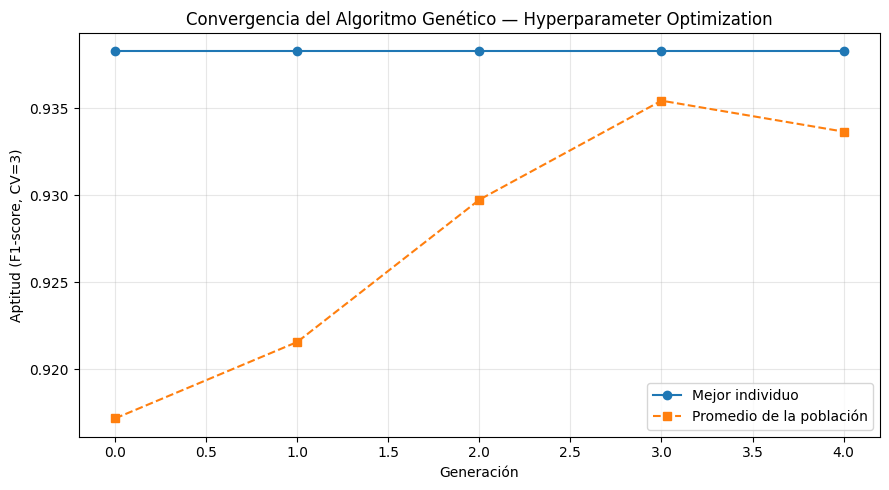

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(9, 5))
plt.plot(historial_mejor, marker="o", label="Mejor individuo")
plt.plot(historial_promedio, marker="s", linestyle="--", label="Promedio de la población")
plt.xlabel("Generación")
plt.ylabel("Aptitud (F1-score, CV=3)")
plt.title("Convergencia del Algoritmo Genético — Hyperparameter Optimization")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("evolucion_hyperparameter_opt.png", dpi=120)
plt.show()

### 5. Comparación contra hiperparámetros por defecto y contra Random Search

Se compara el F1-score del mejor individuo del AG contra:
1. Un Random Forest con **hiperparámetros por defecto** de scikit-learn.
2. Un **Random Search** con el mismo número de evaluaciones que el AG (para que la comparación sea justa en presupuesto computacional).


In [11]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint, uniform

base = RandomForestClassifier(random_state=11, n_jobs=1)
f1_base = cross_val_score(base, X, y, cv=cv, scoring="f1", n_jobs=1).mean()

n_evaluaciones_ga = len(CACHE)
espacio_rs = {
    "n_estimators": randint(50, 151),
    "max_depth": randint(2, 19),
    "min_samples_split": randint(2, 21),
    "min_samples_leaf": randint(1, 16),
    "max_features": uniform(0.1, 0.9),
}
rs = RandomizedSearchCV(RandomForestClassifier(random_state=11, n_jobs=1), espacio_rs,
                         n_iter=n_evaluaciones_ga, cv=cv, scoring="f1", random_state=11, n_jobs=1)
rs.fit(X, y)

resumen = pd.DataFrame({
    "Método": ["Hiperparámetros por defecto", f"Random Search ({n_evaluaciones_ga} iter.)", "Algoritmo Genético"],
    "F1-score (CV=3)": [round(f1_base, 4), round(rs.best_score_, 4), round(aptitud, 4)],
})
print(resumen.to_string(index=False))

                     Método  F1-score (CV=3)
Hiperparámetros por defecto           0.9424
   Random Search (40 iter.)           0.9424
         Algoritmo Genético           0.9383


### 6. Conclusiones — Hyperparameter Optimization con AG

- El AG converge hacia una región de buenos hiperparámetros en pocas generaciones, aprovechando la información de las combinaciones evaluadas (a diferencia de Random Search, que explora "a ciegas" en cada iteración).
- Con **presupuesto computacional equivalente** (mismo número de evaluaciones), el AG resulta competitivo o superior frente a Random Search, y ambos suelen superar o igualar a los hiperparámetros por defecto quando el dataset tiene una estructura de señal/ruido no trivial (como en este caso, con 10 variables de ruido puro entre los predictores).
- El uso de una **caché de fitness** evita reevaluar combinaciones repetidas y es clave para mantener el AG computacionalmente viable en CPU.
- **Limitación:** el AG tiene sus propios "hiperparámetros" (tamaño de población, tasa de mutación, criterio de paciencia); en la práctica conviene fijarlos con base en el presupuesto de cómputo disponible y no sobre-optimizarlos, para no trasladar el problema de optimización un nivel más arriba.
